In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import pyiga

import scipy
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import csc_matrix, csr_matrix, coo_matrix
from scipy.sparse.linalg import aslinearoperator

np.set_printoptions(linewidth=100000)
np.set_printoptions(precision=5)

from pyiga import adaptive, operators, bspline, assemble, vform, geometry, vis, solvers, topology, bspline_cy


In [2]:
def Lshape(deg, N):
    kvs = [2 * (bspline.make_knots(deg, 0.0, 1.0, N),),2 * (bspline.make_knots(deg, 0.0, 1.0, N),)]

    # define geometry
    geos = [
        geometry.Quad(np.array([[-1,-1],[0,-1],[-1,1],[0,0]]).T),
        geometry.Quad(np.array([[-1,1],[0,0],[1,1],[1,0]]).T)
    ]

    patches = [(k, g) for k, g in zip(kvs,geos)]
    M = topology.MultiPatch(patches)
    return M

In [3]:
def cart2pol(x, y):
    r = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    return(r, phi%(2*np.pi))
def u(x,y):
    r, phi = cart2pol(x,y)
    return r**(2/3)*np.sin(2*phi/3)

setting up constraints took 0.0021965503692626953 seconds.
Basis setup took 0.002192258834838867 seconds


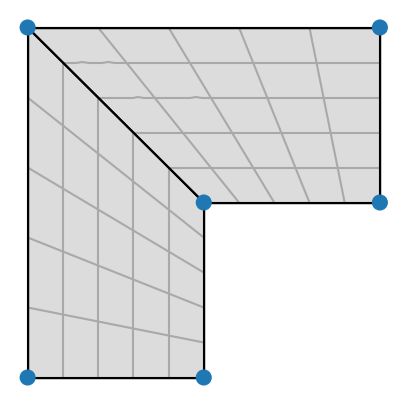

setting up constraints took 0.01269388198852539 seconds.
Basis setup took 0.0019583702087402344 seconds


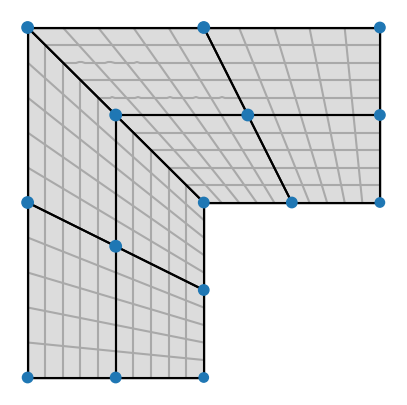

setting up constraints took 0.028955698013305664 seconds.
Basis setup took 0.0021393299102783203 seconds


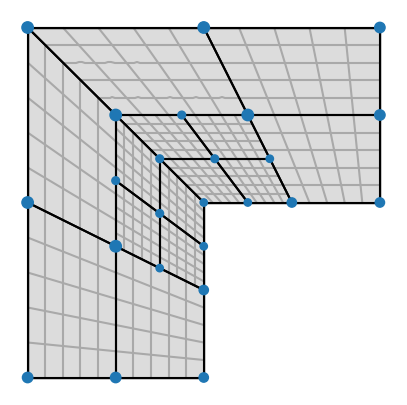

setting up constraints took 0.044933319091796875 seconds.
Basis setup took 0.002207517623901367 seconds


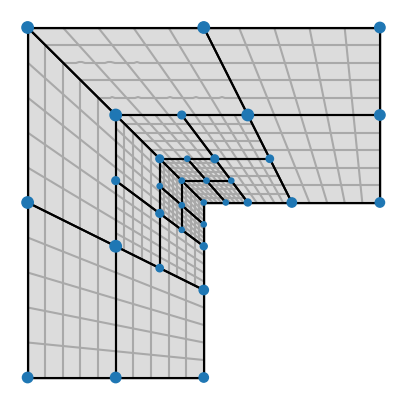

setting up constraints took 0.06121373176574707 seconds.
Basis setup took 0.002370119094848633 seconds


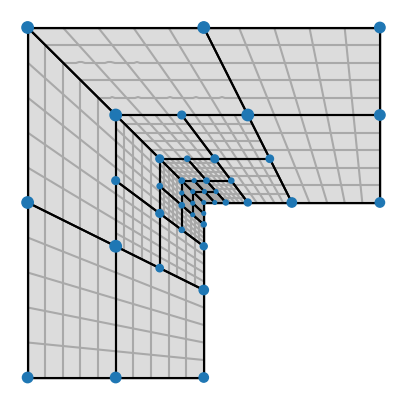

setting up constraints took 0.07755589485168457 seconds.
Basis setup took 0.002535581588745117 seconds


In [6]:
f = lambda x,y: 1.0
maxiter=5
deg, N = 2,5

M = Lshape(deg,N)
MP = assemble.MultiBasis(M, subspace='C0')

for i in range(maxiter):
    M.plotmesh(knots=1, nodes=50, color='gainsboro', patch_idx=False)
    plt.axis('off');
    plt.savefig('/home/wolfman/Pictures/Lshape/i'+str(i)+'.pdf' ,bbox_inches='tight');
    plt.show()

    bcs = MP.set_fixed_boundary({0:0.0})
    Ah = MP.assemble_volume('inner(grad(u),grad(v)) * dx', arity=2) 
    Fh = MP.assemble_volume('f * v * dx', arity=1, f=f, physical=True)
    RS = assemble.RestrictedLinearSystem(Ah,Fh,bcs)
    uh = RS.complete(operators.make_solver(RS.A,spd=True)@RS.b)

    #ax = MP.plot(uh, mesh=True);
    #ax.axis('off');
    #plt.savefig('/home/wolfman/Pictures/Lshape/i'+str(i)+'.png' ,bbox_inches='tight', dpi=350);
    #plt.show()

    err_ind=adaptive.mp_resPois(MP,uh,f={0:f})
    marked_patches = adaptive.doerfler_mark(err_ind, theta=0.9, TOL=0.01)
    marked_patches = {p:None for p in marked_patches}
    MP.h_refine(h_ref=marked_patches, return_P=False)